1. Klasifikasi Flynn digunakan untuk mengelompokkan sistem berdasarkan jumlah aliran instruksi dan
aliran data yang diproses secara bersamaan.
1.1 Operasi arr + arr pada NumPy dapat dikategorikan sebagai SIMD (Single Instruction, Multiple Data)
   Satu operasi penjumlahan diterapkan pada banyak elemen array secara serentak/tervektorisasi.
1.2 Program Python biasa yang memproses data baris demi baris tanpa threading atau multiprocessing 
   dikategorikan sebagai SISD (Single Instruction, Single Data). Pada satu waktu, satu aliran 
   instruksi bekerja terhadap satu data.
1.3 Cluster komputer yang masing-masing node menjalankan simulasi yang berbeda secara independen 
   termasuk MIMD (Multiple Instruction, Multiple Data). Setiap node dapat menjalankan instruksi/
   program yang berbeda dan menggunakan data yang berbeda pula.

2. Analisis Amdahl 
Fungsi amdahl_speedup() menghitung speedup teoritis berdasarkan Hukum Amdahl. 
P adalah bagian program yang dapat diparalelkan, sedangkan N adalah jumlah prosesor.
2.1 hitung speedup N = 2, 4, 8, 16, 32, 64.

In [4]:
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + (P / N))

In [5]:
P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

for N in N_values:
    speedup = amdahl_speedup(P,N)
    print(f"N = {N:2d} -> Speedup = {speedup:.4f}")


N =  2 -> Speedup = 1.7391
N =  4 -> Speedup = 2.7586
N =  8 -> Speedup = 3.9024
N = 16 -> Speedup = 4.9231
N = 32 -> Speedup = 5.6637
N = 64 -> Speedup = 6.1244


2.2 plot speedup vs N 

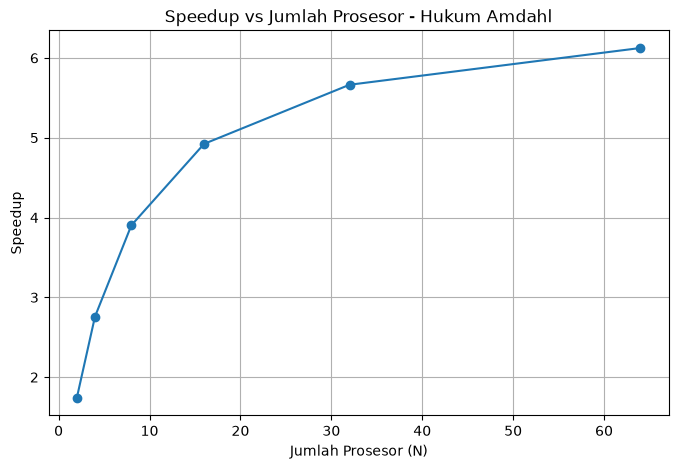

In [6]:
import matplotlib.pyplot as plt

speedups = [amdahl_speedup(P, N) for N in N_values]

plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker='o')

plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup")
plt.title("Speedup vs Jumlah Prosesor - Hukum Amdahl")
plt.grid(True)

plt.show()

2.3 deminishing returns
Diminishing returns mulai terlihat cukup jelas setelah sekitar N = 16 prosesor.
Perbandingannya:
N = 2 → 4: speedup naik sekitar 1,0195
N = 4 → 8: naik sekitar 1,1438
N = 8 → 16: naik sekitar 1,0206
N = 16 → 32: hanya naik sekitar 0,7406
N = 32 → 64: hanya naik sekitar 0,4607

Semakin banyak prosesor yang digunakan, bagian program yang paralel memang semakin 
cepat, tetapi bagian 15% yang serial tetap menjadi batas kecepatan. Oleh karena itu, 
penambahan prosesor akhirnya memberikan peningkatan performa yang semakin kecil.

3. Benchmark mandiri
3.1 Mengukur Waktu dengan time.perf_counter()

In [13]:
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt

def fibonacci_naif(n):
    """Menghitung Fibonacci secara rekursif tanpa memoization."""
    if n <= 1:
        return n
    return fibonacci_naif(n - 1) + fibonacci_naif(n - 2)

In [9]:
ukuran_input = [24, 28, 30, 32]
hasil = []

for n in ukuran_input:
    # Pengukuran menggunakan time.perf_counter()
    mulai = time.perf_counter()
    nilai_fib = fibonacci_naif(n)
    waktu_perf = time.perf_counter() - mulai

    # Pengukuran menggunakan timeit
    timer = timeit.Timer(lambda: fibonacci_naif(n))
    waktu_timeit = min(timer.repeat(repeat=3, number=1))

    hasil.append({
        "n": n,
        "Fibonacci ke-n": nilai_fib,
        "perf_counter (detik)": waktu_perf,
        "timeit terbaik (detik)": waktu_timeit
    })

tabel_hasil = pd.DataFrame(hasil)
display(tabel_hasil)

,n,Fibonacci ke-n,perf_counter (detik),timeit terbaik (detik)
0,24,46368,0.027098,0.016950
1,28,317811,0.103868,0.092946
2,30,832040,0.334734,0.319734
3,32,2178309,0.837380,0.732508


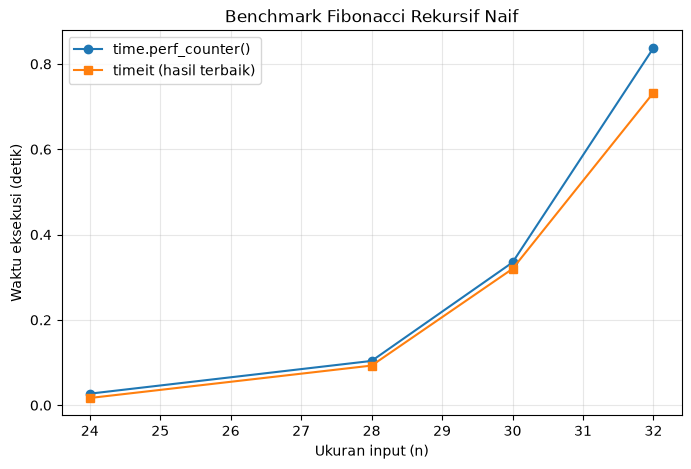

In [10]:
# Plot perbandingan waktu eksekusi
plt.figure(figsize=(8, 5))
plt.plot(tabel_hasil["n"], tabel_hasil["perf_counter (detik)"],
         marker="o", label="time.perf_counter()")
plt.plot(tabel_hasil["n"], tabel_hasil["timeit terbaik (detik)"],
         marker="s", label="timeit (hasil terbaik)")

plt.title("Benchmark Fibonacci Rekursif Naif")
plt.xlabel("Ukuran input (n)")
plt.ylabel("Waktu eksekusi (detik)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Refleksi Singkat
Hukum Amdahl lebih relevan ketika ukuran masalah relatif tetap dan kita ingin mengetahui 
seberapa besar peningkatan performa yang dapat diperoleh dengan menambah jumlah prosesor.
Amdahl memperhitungkan bagian program yang tidak dapat diparalelkan sehingga menunjukkan
adanya batas speedup. Contohnya adalah menjalankan program pengolahan data dengan ukuran 
input yang tetap menggunakan jumlah core yang semakin banyak. Sebaliknya, Hukum Gustafson 
lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar.
Dalam kondisi tersebut, semakin banyak prosesor memungkinkan pekerjaan yang lebih besar 
diselesaikan dalam waktu yang relatif sama. Contohnya adalah simulasi cuaca atau simulasi 
ilmiah yang dapat menggunakan lebih banyak data ketika jumlah komputer ditambah. Jadi, Amdahl 
berfokus pada percepatan untuk masalah dengan ukuran tetap, sedangkan Gustafson berfokus
pada peningkatan ukuran masalah yang dapat diselesaikan ketika sumber daya bertambah.